# 03 - Two-Period DiD: NYC

Estimate the ATT of Local Law 18 using a simple two-period DiD. NYC vs control cities, pre vs post September 2023.

In [1]:
# Data setup
# Set DATA_FILE to 'city_month_panel.parquet' after running build_real_panel.py
DATA_FILE = "city_month_panel.parquet"       # synthetic data (real not downloaded)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel = pd.read_parquet(DATA_DIR / DATA_FILE)
panel["month"] = pd.to_datetime(panel["month"])

regs = pd.read_csv("../data/regulations.csv", parse_dates=["enforcement_date"])

print(f"Panel: {panel.shape}  |  Cities: {sorted(panel['city'].unique())}")
print(f"Date range: {panel['month'].min().date()} to {panel['month'].max().date()}")

Panel: (288, 15)  |  Cities: ['Amsterdam', 'Barcelona', 'Florence', 'Lisbon', 'New York City', 'Vienna']
Date range: 2021-01-01 to 2024-12-01


In [2]:
import statsmodels.formula.api as smf

## Build two-period dataset

In [3]:
NYC_TREAT = pd.Timestamp("2023-09-01")
panel["treat_nyc"] = (panel["city"] == "New York City").astype(int)
panel["post_nyc"]  = (panel["month"] >= NYC_TREAT).astype(int)
panel["did_nyc"]   = panel["treat_nyc"] * panel["post_nyc"]

# Exclude Florence (also treated) from the two-period DiD control group
did_data = panel[panel["city"] != "Florence"].copy()
print(f"DiD sample: {did_data['city'].unique()}")

DiD sample: <ArrowStringArray>
['New York City', 'Amsterdam', 'Lisbon', 'Vienna', 'Barcelona']
Length: 5, dtype: str


## Model 1 - Basic 2x2 DiD

In [4]:
m1 = smf.ols(
    "log_listings ~ treat_nyc + post_nyc + did_nyc",
    data=did_data
).fit(cov_type="HC3")

att = m1.params["did_nyc"]
ci  = m1.conf_int().loc["did_nyc"]
print(f"ATT (log_listings) = {att:.4f}  95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"In levels: {(np.exp(att)-1)*100:+.1f}% change in listings")

ATT (log_listings) = -1.6307  95% CI [-1.7917, -1.4696]
In levels: -80.4% change in listings


## Model 2 - TWFE with city and month FE (preferred)

In [5]:
from linearmodels.panel import PanelOLS

did_idx = did_data.set_index(["city", "month"])
fe = PanelOLS(
    did_idx["log_listings"],
    did_idx[["did_nyc"]],
    entity_effects=True,
    time_effects=True,
).fit(cov_type="clustered", cluster_entity=True)

att_fe = fe.params["did_nyc"]
ci_fe  = fe.conf_int().loc["did_nyc"]
print(f"TWFE ATT (log_listings) = {att_fe:.4f}  95% CI [{ci_fe['lower']:.4f}, {ci_fe['upper']:.4f}]")
print(f"In levels: {(np.exp(att_fe)-1)*100:+.1f}% change in listings")
print()
print(fe.summary.tables[1])

TWFE ATT (log_listings) = -1.6307  95% CI [-1.6569, -1.6044]
In levels: -80.4% change in listings

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
did_nyc       -1.6307     0.0133    -122.68     0.0000     -1.6569     -1.6044


## All outcomes

In [6]:
results = {}
for outcome in ["log_listings","log_price","availability_rate","entire_home_share"]:
    fe_m = PanelOLS(
        did_idx[outcome],
        did_idx[["did_nyc"]],
        entity_effects=True, time_effects=True,
    ).fit(cov_type="clustered", cluster_entity=True)
    b  = fe_m.params["did_nyc"]
    ci = fe_m.conf_int().loc["did_nyc"]
    results[outcome] = (b, ci["lower"], ci["upper"])
    print(f"{outcome:<22}  ATT = {b:+.4f}  [{ci['lower']:+.4f}, {ci['upper']:+.4f}]")

log_listings            ATT = -1.6307  [-1.6569, -1.6044]
log_price               ATT = +0.1052  [+0.0936, +0.1168]
availability_rate       ATT = -0.1304  [-0.1351, -0.1256]


entire_home_share       ATT = -0.2786  [-0.2803, -0.2768]


## Effect across all four outcomes

LL18 should hammer listing counts; its effect on price, availability and room-type mix is the more interesting question. TWFE ATTs (city + month FE, city-clustered) across outcomes:

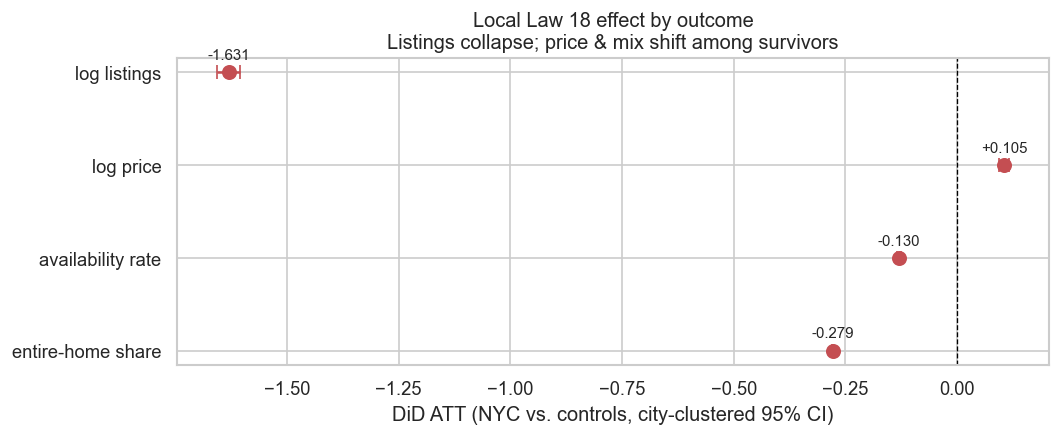

In [7]:
labels = {"log_listings":"log listings","log_price":"log price",
          "availability_rate":"availability rate","entire_home_share":"entire-home share"}
fig, ax = plt.subplots(figsize=(9, 3.8))
keys = list(results.keys())
y = np.arange(len(keys))[::-1]
for yi,k in zip(y, keys):
    b,lo,hi = results[k]
    col = "#C44E52" if (lo>0 or hi<0) else "#999999"
    ax.errorbar(b, yi, xerr=[[b-lo],[hi-b]], fmt="o", ms=8, capsize=4, color=col)
    ax.text(b, yi+0.14, f"{b:+.3f}", ha="center", fontsize=9)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y); ax.set_yticklabels([labels[k] for k in keys])
ax.set_xlabel("DiD ATT (NYC vs. controls, city-clustered 95% CI)")
ax.set_title("Local Law 18 effect by outcome\nListings collapse; price & mix shift among survivors")
plt.tight_layout(); plt.savefig(OUT_DIR/"03_did_outcomes.png", bbox_inches="tight"); plt.show()

**Takeaway.** The listings effect is large and unambiguous. Effects on price and entire-home share describe how the *surviving* market re-composes after the registration requirement forced out non-compliant whole-unit listings. Note the standard two-period DiD caveat: with one treated city it leans on the parallel-trends assumption that notebook 04's event study tests directly.